In [288]:
import os
import shutil
from datetime import datetime
import json

import h5py
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

# 0. Helpers

In [289]:
def backup_data(data_filename):
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    filename_only = os.path.basename(data_filename)
    name, ext = os.path.splitext(filename_only)
    backup_name = f"{name}_{timestamp}{ext}"
    backup_path = os.path.join('data_backups', backup_name)
    shutil.copy2(data_filename, backup_path)

def save_nested_dict_to_hdf5(filename, data, save_backup=True):

    if save_backup:
        backup_data(filename)

    with h5py.File(filename, 'w') as f:
        def _save_dict(group, dictionary):
            for key, value in dictionary.items():
                if isinstance(value, dict):
                    subgroup = group.create_group(str(key))
                    _save_dict(subgroup, value)
                elif isinstance(value, np.ndarray):
                    group.create_dataset(key, data=value, compression='gzip')
                elif isinstance(value, list):
                    group.create_dataset(key, data=np.array(value), compression='gzip')
                else:
                    group.attrs[key] = value  # Store scalars as attributes
        
        _save_dict(f, data)

def update_data_file(filename, data, keys, save_backup=True):
    if save_backup:
        backup_data(filename)
    
    with h5py.File(filename, 'a') as f:  # Open in append mode
        def _navigate_to_parent(group, key_path):
            """Navigate to the parent group of the target location"""
            current_group = group
            for key in key_path[:-1]:  # All keys except the last one
                if str(key) in current_group:
                    current_group = current_group[str(key)]
                else:
                    # Create the group if it doesn't exist
                    current_group = current_group.create_group(str(key))
            return current_group
        
        def _save_data_at_location(group, key, value):
            """Save data at a specific location, replacing if it exists"""
            # Remove existing data if it exists
            if key in group:
                del group[key]
            
            # Save new data
            if isinstance(value, dict):
                subgroup = group.create_group(key)
                _save_dict(subgroup, value)
            elif isinstance(value, np.ndarray):
                group.create_dataset(key, data=value, compression='gzip')
            elif isinstance(value, list):
                group.create_dataset(key, data=np.array(value), compression='gzip')
            else:
                group.attrs[key] = value  # Store scalars as attributes
        
        def _save_dict(group, dictionary):
            """Helper function to save nested dictionaries"""
            for key, value in dictionary.items():
                _save_data_at_location(group, str(key), value)
        
        # Navigate to the parent location
        parent_group = _navigate_to_parent(f, keys)
        
        # Save the data at the final key location
        final_key = str(keys[-1])
        _save_data_at_location(parent_group, final_key, data)

In [290]:
def load_nested_dict_from_hdf5(filename):
    def _load_dict(group):
        result = {}
        for key in group.keys():
            if isinstance(group[key], h5py.Group):
                result[key] = _load_dict(group[key])
            else:
                result[key] = group[key][()]  # Load dataset
        
        # Load attributes (scalars)
        for key, value in group.attrs.items():
            result[key] = value
            
        return result
    
    with h5py.File(filename, 'r') as f:
        return _load_dict(f)

def print_tree(data, max_level=None):
    def __print_tree_recursive(root, level=0):
        if isinstance(root, dict):
            if not max_level is None and level == max_level:
                return
            level_str = '- '*level
            for key in root:
                print(f'{level_str}{key}')
                __print_tree_recursive(root[key], level+1)
    __print_tree_recursive(data)

In [291]:
data_filename = 'bond_order_data.h5'

data = load_nested_dict_from_hdf5(data_filename)

In [292]:
print_tree(data['data'], max_level=3)

coupling_point_1
- highest
- - (1, 2)
- - (2, 3)
- - (3, 4)
- - (4, 5)
- - (5, 6)
- - (6, 7)
- - (7, 8)
- - bond_order_total
- - bond_order_total_corrected
- - bond_order_total_error
- - bond_order_total_error_corrected
coupling_point_2
- highest
- - (1, 2)
- - (2, 3)
- - (3, 4)
- - (4, 5)
- - (5, 6)
- - (6, 7)
- - (7, 8)
- - bond_order_total
- - bond_order_total_corrected
- - bond_order_total_error
- - bond_order_total_error_corrected
coupling_point_4
- highest
- - (1, 2)
- - (2, 3)
- - (3, 4)
- - (4, 5)
- - (5, 6)
- - (6, 7)
- - (7, 8)
- - bond_order_total
- - bond_order_total_corrected
- - bond_order_total_error
- - bond_order_total_error_corrected


In [293]:
print_tree(data['simulation'], max_level=5)

highest
- no_dephasing
- - coupling_point_1
- - - (1, 2)
- - - - population_difference
- - - - beamsplitter_time
- - - - bond_order_value
- - - - bond_order_value_BS
- - - (2, 3)
- - - - population_difference
- - - - beamsplitter_time
- - - - bond_order_value
- - - - bond_order_value_BS
- - - (3, 4)
- - - - population_difference
- - - - beamsplitter_time
- - - - bond_order_value
- - - - bond_order_value_BS
- - - (4, 5)
- - - - population_difference
- - - - beamsplitter_time
- - - - bond_order_value
- - - - bond_order_value_BS
- - - (5, 6)
- - - - population_difference
- - - - beamsplitter_time
- - - - bond_order_value
- - - - bond_order_value_BS
- - - (6, 7)
- - - - population_difference
- - - - beamsplitter_time
- - - - bond_order_value
- - - - bond_order_value_BS
- - - (7, 8)
- - - - population_difference
- - - - beamsplitter_time
- - - - bond_order_value
- - - - bond_order_value_BS
- - - bond_order_total
- - - bond_order_total_BS
- - coupling_point_2
- - - (1, 2)
- - - - population_

# 1. Setup

In [294]:
coupling_point = 'coupling_point_1'
# coupling_point = 'coupling_point_2'
# coupling_point = 'coupling_point_4'

eigenstate = 'highest'
# eigenstate = 'lowest'

dephasing = 'no_dephasing'

In [295]:
# Rung pairs for bond order
pairs = [(i, i+1) for i in range(1, 8)]
print(pairs)
print(len(pairs))

[(1, 2), (2, 3), (3, 4), (4, 5), (5, 6), (6, 7), (7, 8)]
7


In [296]:
# Coupling point metadata
coupling_point_to_ratio = {
    'coupling_point_1': 1,
    'coupling_point_2': 2,
    'coupling_point_3': 3,
    'coupling_point_4': 1,
    'coupling_point_5': 2,
    'coupling_point_6': 4
}

all_coupling_points = [f'coupling_point_{i}' for i in range(1, 7)]

# 2. Bond Order vs Time

In [297]:
def plot_bond_order_time(
    ax,
    data,
    coupling_point,
    eigenstate,
    pair,
    marker_size     = 3,
    y_lim           = (-1, 1),
    show_annotation = True,
    font_size       = 10,
):
    """Plot bond order (population difference) vs time for a single rung pair."""
    pair_data = data['data'][coupling_point][eigenstate][str(pair)]
    
    times = pair_data['times']
    beamsplitter_time = pair_data['beamsplitter_time'] * 1e3  # convert to ns
    population_difference = pair_data['population_difference']
    bond_order_value = pair_data['bond_order_value']
    
    # Main plot
    ax.plot(times, population_difference, linestyle='', marker='o', markersize=marker_size, label='data')
    ax.axvline(beamsplitter_time, color='r', alpha=0.4, linestyle='--', label='BS time')
    
    # Annotation at beamsplitter point
    if show_annotation:
        ax.annotate(
            f'{bond_order_value:.3f}',
            xy=(beamsplitter_time, bond_order_value),
            xytext=(beamsplitter_time + 5, bond_order_value + 0.1),
            arrowprops=dict(arrowstyle='->', color='black'),
            bbox=dict(boxstyle='round,pad=0.3', fc='yellow', alpha=0.3),
            fontsize=font_size - 2
        )
    
    ax.set_xlabel('Time (ns)', fontsize=font_size - 2)
    ax.set_ylabel('Population Difference', fontsize=font_size - 2)
    ax.set_title(f'Rung {pair}', fontsize=font_size)
    ax.set_ylim(y_lim)
    ax.legend(fontsize=font_size - 3)

In [298]:
def plot_bond_order_time_grid(
    data,
    coupling_point,
    eigenstate,
    pairs,
    nrows           = 2,
    ncols           = 4,
    marker_size     = 3,
    y_lim           = (-1, 1),
    figsize         = (14, 6),
):
    """Grid of bond order vs time plots for all pairs."""
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes_flat = axes.flat
    
    for idx, pair in enumerate(pairs):
        if idx >= nrows * ncols:
            break
        plot_bond_order_time(
            axes_flat[idx], data, coupling_point, eigenstate, pair,
            marker_size=marker_size, y_lim=y_lim
        )
    
    # Hide unused axes
    for idx in range(len(pairs), nrows * ncols):
        axes_flat[idx].set_visible(False)
    
    plt.tight_layout()
    plt.show()

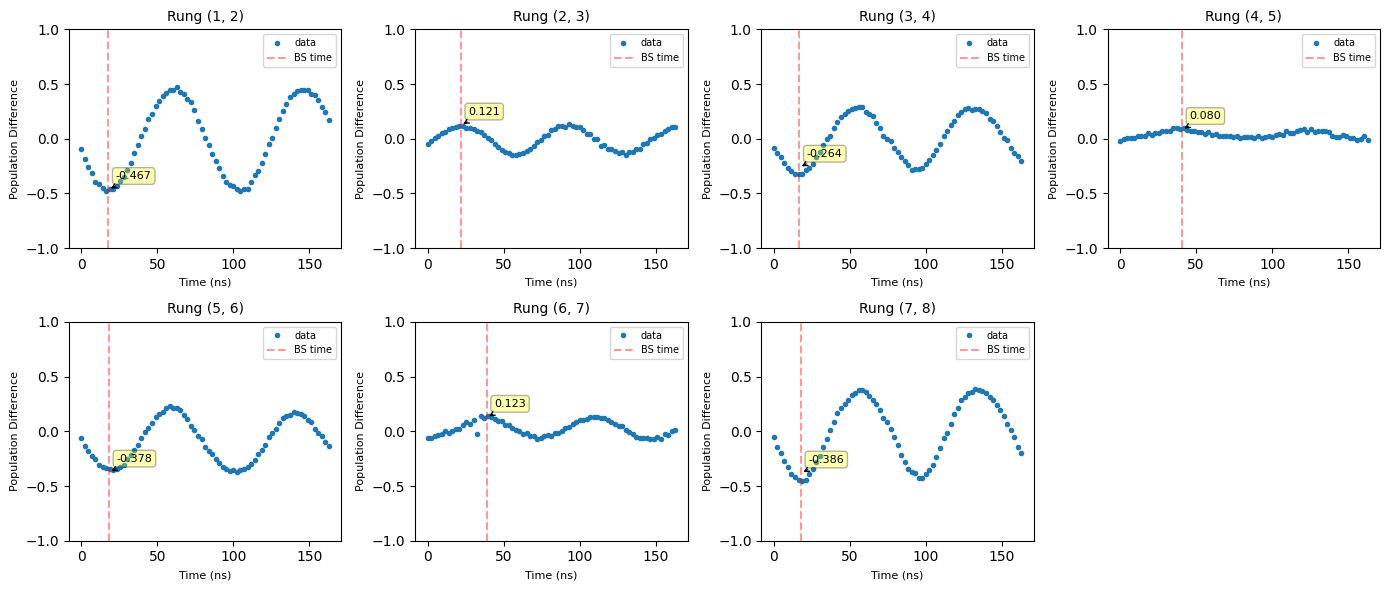

In [299]:
# Example usage
plot_bond_order_time_grid(data, coupling_point, eigenstate, pairs)

# 3. Bond Order Values vs Rung

In [300]:
def plot_bond_order_values(
    ax,
    data,
    coupling_point,
    eigenstate,
    pairs,
    use_corrected   = True,
    marker          = 'o',
    linestyle       = '--',
    color           = 'blue',
    label           = 'data',
    y_lim           = (-1, 1),
    font_size       = 12,
    show_grid       = True,
):
    """Plot bond order values across all rungs."""
    key = 'bond_order_value_corrected' if use_corrected else 'bond_order_value'
    bond_order_values = [data['data'][coupling_point][eigenstate][str(pair)][key] for pair in pairs]
    
    ax.plot(range(len(pairs)), bond_order_values, marker=marker, linestyle=linestyle, color=color, label=label)
    
    ax.set_xlabel('Rung', fontsize=font_size - 2)
    ax.set_xticks(range(len(pairs)))
    ax.set_xticklabels([str(pair) for pair in pairs], fontsize=font_size - 3)
    ax.set_ylabel('Bond Order', fontsize=font_size - 2)
    ax.set_ylim(y_lim)
    
    if show_grid:
        ax.grid(True, alpha=0.3)
    
    ax.legend(fontsize=font_size - 2)

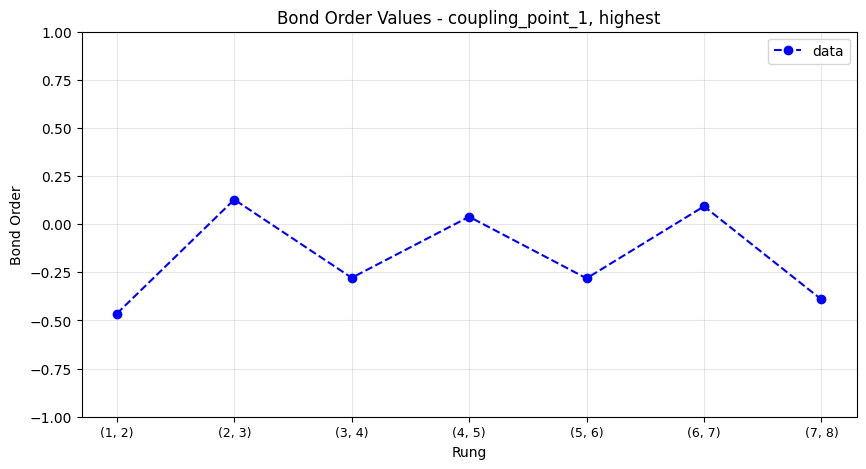

In [301]:
# Example usage
fig, ax = plt.subplots(figsize=(10, 5))
plot_bond_order_values(ax, data, coupling_point, eigenstate, pairs)
ax.set_title(f'Bond Order Values - {coupling_point}, {eigenstate}')
plt.show()

# 4. Simulation Bond Order

In [302]:
def plot_bond_order_sim(
    ax,
    data,
    coupling_point,
    eigenstate,
    dephasing,
    pairs,
    plot_BS         = True,
    plot_operator   = True,
    y_lim           = (-1, 1),
    font_size       = 12,
    show_grid       = True,
):
    """Plot simulation bond order values (beamsplitter and/or operator measurement)."""
    sim_block = data['simulation'][eigenstate][dephasing][coupling_point]
    
    if plot_BS:
        bond_order_BS = [sim_block[str(pair)]['bond_order_value_BS'] for pair in pairs]
        ax.plot(range(len(pairs)), bond_order_BS, marker='o', linestyle='--', 
                color='blue', label='sim (BS)')
    
    if plot_operator:
        bond_order_op = [sim_block[str(pair)]['bond_order_value'] for pair in pairs]
        ax.plot(range(len(pairs)), bond_order_op, marker='o', linestyle='--', 
                color='red', label='sim (operator)')
    
    ax.set_xlabel('Rung', fontsize=font_size - 2)
    ax.set_xticks(range(len(pairs)))
    ax.set_xticklabels([str(pair) for pair in pairs], fontsize=font_size - 3)
    ax.set_ylabel('Bond Order', fontsize=font_size - 2)
    ax.set_ylim(y_lim)
    
    if show_grid:
        ax.grid(True, alpha=0.3)
    
    ax.legend(fontsize=font_size - 2)

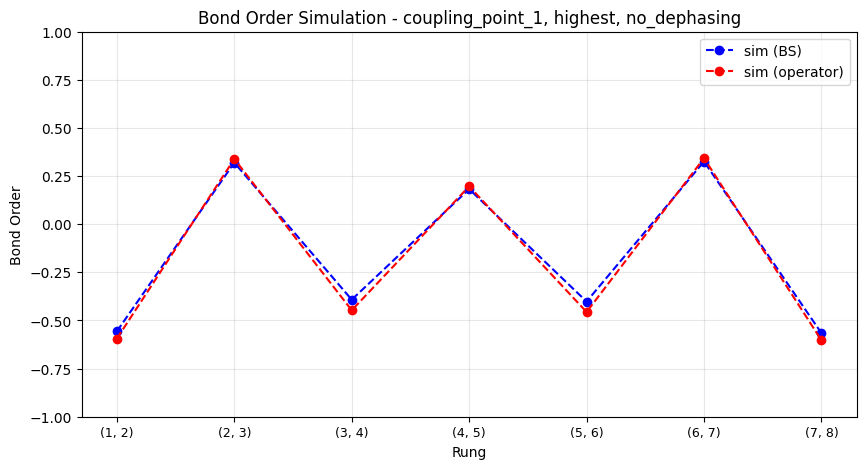

In [303]:
# Example usage
fig, ax = plt.subplots(figsize=(10, 5))
plot_bond_order_sim(ax, data, coupling_point, eigenstate, dephasing, pairs)
ax.set_title(f'Bond Order Simulation - {coupling_point}, {eigenstate}, {dephasing}')
plt.show()

# 5. Data with Simulation

In [304]:
def plot_bond_order_data_and_sim(
    ax,
    data,
    coupling_point,
    eigenstate,
    dephasing,
    pairs,
    use_corrected       = True,
    plot_sim_BS         = True,
    plot_sim_operator   = True,
    y_lim               = (-1, 1),
    font_size           = 12,
    show_grid           = True,
):
    """Plot data and simulation bond order values together."""
    # Data
    key = 'bond_order_value_corrected' if use_corrected else 'bond_order_value'
    bond_order_data = [data['data'][coupling_point][eigenstate][str(pair)][key] for pair in pairs]
    ax.plot(range(len(pairs)), bond_order_data, marker='x', linestyle='', 
            color='blue', label='data', markersize=8)
    
    # Simulation
    try:
        sim_block = data['simulation'][eigenstate][dephasing][coupling_point]
        
        if plot_sim_BS:
            bond_order_BS = [sim_block[str(pair)]['bond_order_value_BS'] for pair in pairs]
            ax.plot(range(len(pairs)), bond_order_BS, marker='o', linestyle='--', 
                    color='red', label='sim (BS)')
        
        if plot_sim_operator:
            bond_order_op = [sim_block[str(pair)]['bond_order_value'] for pair in pairs]
            ax.plot(range(len(pairs)), bond_order_op, marker='o', linestyle='--', 
                    color='orange', label='sim (operator)')
    except KeyError:
        pass  # No sim data available
    
    ax.set_xlabel('Rung', fontsize=font_size - 2)
    ax.set_xticks(range(len(pairs)))
    ax.set_xticklabels([str(pair) for pair in pairs], fontsize=font_size - 3)
    ax.set_ylabel('Bond Order', fontsize=font_size - 2)
    ax.set_ylim(y_lim)
    
    if show_grid:
        ax.grid(True, alpha=0.3)
    
    ax.legend(fontsize=font_size - 2)

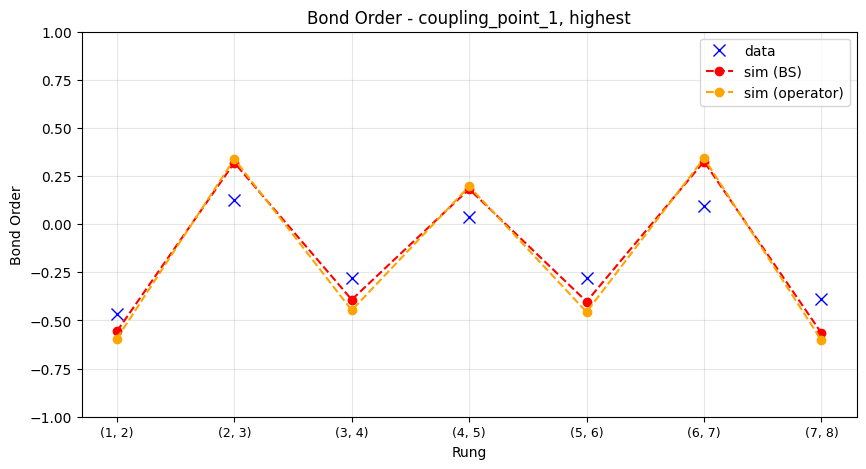

In [305]:
# Example usage
fig, ax = plt.subplots(figsize=(10, 5))
plot_bond_order_data_and_sim(ax, data, coupling_point, eigenstate, dephasing, pairs)
ax.set_title(f'Bond Order - {coupling_point}, {eigenstate}')
plt.show()

# 6. All Coupling Points Comparison

In [306]:
def get_flux_type(coupling_point):
    """Return flux type based on coupling point number."""
    cp_num = int(coupling_point[-1])
    if cp_num in [4, 5, 6]:
        return '0_flux'
    elif cp_num in [1, 2, 3]:
        return 'pi_flux'
    return 'unknown'

def get_available_coupling_points(data):
    """Return list of available coupling points."""
    return list(data['data'].keys())

In [307]:
def plot_bond_order_all_coupling_points(
    ax,
    data,
    eigenstate,
    dephasing,
    pairs,
    coupling_points     = None,
    use_corrected       = True,
    plot_sim            = True,
    y_lim               = (-1, 1),
    font_size           = 12,
    show_grid           = True,
):
    """Plot bond order values for multiple coupling points on same axes."""
    if coupling_points is None:
        coupling_points = get_available_coupling_points(data)
    
    colors = plt.cm.tab10.colors
    
    for idx, cp in enumerate(coupling_points):
        color = colors[idx % len(colors)]
        
        # Data
        if cp in data['data']:
            key = 'bond_order_value_corrected' if use_corrected else 'bond_order_value'
            try:
                bond_order = [data['data'][cp][eigenstate][str(pair)][key] for pair in pairs]
                ax.plot(range(len(pairs)), bond_order, marker='o', linestyle='--', 
                        color=color, label=f'{cp} data')
            except KeyError:
                pass
        
        # Simulation
        if plot_sim:
            try:
                sim_block = data['simulation'][eigenstate][dephasing][cp]
                bond_order_sim = [sim_block[str(pair)]['bond_order_value_BS'] for pair in pairs]
                ax.plot(range(len(pairs)), bond_order_sim, marker='x', linestyle='-', 
                        color=color, alpha=0.5, label=f'{cp} sim')
            except KeyError:
                pass
    
    ax.set_xlabel('Rung', fontsize=font_size - 2)
    ax.set_xticks(range(len(pairs)))
    ax.set_xticklabels([str(pair) for pair in pairs], fontsize=font_size - 3)
    ax.set_ylabel('Bond Order', fontsize=font_size - 2)
    ax.set_ylim(y_lim)
    
    if show_grid:
        ax.grid(True, alpha=0.3)
    
    ax.legend(fontsize=font_size - 3, loc='best')

In [308]:
def plot_bond_order_grid_by_coupling_point(
    data,
    eigenstate,
    dephasing,
    pairs,
    coupling_points     = None,
    use_corrected       = True,
    nrows               = 2,
    ncols               = 3,
    figsize             = (14, 8),
    y_lim               = (-1, 1),
):
    """Grid of bond order plots, one per coupling point."""
    if coupling_points is None:
        coupling_points = get_available_coupling_points(data)
    
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes_flat = axes.flat
    
    for idx, cp in enumerate(coupling_points):
        if idx >= nrows * ncols:
            break
        ax = axes_flat[idx]
        
        flux_type = get_flux_type(cp)
        
        plot_bond_order_data_and_sim(
            ax, data, cp, eigenstate, dephasing, pairs,
            use_corrected=use_corrected, y_lim=y_lim
        )
        ax.set_title(f'{cp} ({flux_type})')
    
    # Hide unused axes
    for idx in range(len(coupling_points), nrows * ncols):
        axes_flat[idx].set_visible(False)
    
    plt.tight_layout()
    plt.savefig(f'saved_figures/cp{coupling_point[-1]}_{eigenstate[:3]}_{dephasing}_bondorderrung.png', dpi=300, bbox_inches='tight')
    plt.show()

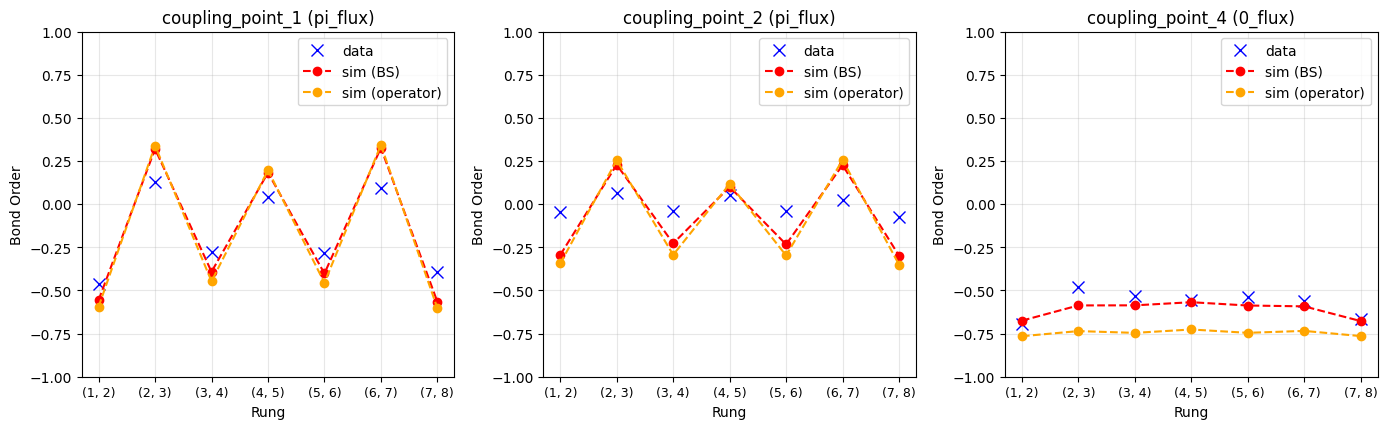

In [309]:
# Example usage
plot_bond_order_grid_by_coupling_point(data, eigenstate, dephasing, pairs)

# 7. Bond Order Parameter vs Coupling Ratio

In [310]:
def extract_bond_order_parameters(
    data,
    eigenstate,
    dephasing,
    coupling_point_to_ratio,
):
    """Extract bond order parameters grouped by flux type."""
    result = {
        '0_flux': {'ratios': [], 'values': [], 'errors': [], 'sim_values': []},
        'pi_flux': {'ratios': [], 'values': [], 'errors': [], 'sim_values': []}
    }
    
    for cp in coupling_point_to_ratio.keys():
        flux_type = get_flux_type(cp)
        ratio = coupling_point_to_ratio[cp]
        
        # Data
        if cp in data['data']:
            try:
                bo_val = data['data'][cp][eigenstate]['bond_order_total_corrected']
                bo_err = data['data'][cp][eigenstate]['bond_order_total_error_corrected']
                result[flux_type]['ratios'].append(ratio)
                result[flux_type]['values'].append(bo_val)
                result[flux_type]['errors'].append(bo_err)
            except KeyError:
                pass
        
        # Simulation
        try:
            bo_sim = data['simulation'][eigenstate][dephasing][cp]['bond_order_total_BS']
            # Only append sim if we have data for same coupling point
            if cp in data['data']:
                result[flux_type]['sim_values'].append(bo_sim)
        except KeyError:
            pass
    
    return result

In [311]:
def plot_bond_order_parameter_vs_ratio(
    ax,
    data,
    eigenstate,
    dephasing,
    coupling_point_to_ratio,
    plot_sim        = True,
    use_abs         = True,
    marker_size     = 8,
    y_lim           = (0, 3),
    font_size       = 12,
    show_grid       = True,
):
    """Plot bond order parameter vs coupling ratio, separated by flux type."""
    params = extract_bond_order_parameters(data, eigenstate, dephasing, coupling_point_to_ratio)
    
    transform = np.abs if use_abs else lambda x: x
    
    # 0 flux data
    if params['0_flux']['ratios']:
        ax.errorbar(
            params['0_flux']['ratios'], 
            transform(params['0_flux']['values']),
            yerr=params['0_flux']['errors'],
            color='blue', marker='o', ms=marker_size, linestyle='',
            capsize=3, label='0 flux'
        )
    
    # pi flux data
    if params['pi_flux']['ratios']:
        ax.errorbar(
            params['pi_flux']['ratios'], 
            transform(params['pi_flux']['values']),
            yerr=params['pi_flux']['errors'],
            color='red', marker='x', ms=marker_size, linestyle='',
            capsize=3, label='π flux'
        )
    
    # Simulation
    if plot_sim:
        if params['0_flux']['sim_values']:
            ax.plot(
                params['0_flux']['ratios'],
                transform(params['0_flux']['sim_values']),
                color='darkblue', marker='o', ms=marker_size, linestyle='-',
                label='0 flux sim'
            )
        if params['pi_flux']['sim_values']:
            ax.plot(
                params['pi_flux']['ratios'],
                transform(params['pi_flux']['sim_values']),
                color='darkred', marker='x', ms=marker_size, linestyle='-',
                label='π flux sim'
            )
    
    ax.set_xlabel('Coupling Ratio', fontsize=font_size - 2)
    ax.set_ylabel('Bond Order Parameter', fontsize=font_size - 2)
    ax.set_ylim(y_lim)
    
    if show_grid:
        ax.grid(True, alpha=0.3)
    
    ax.legend(fontsize=font_size - 2)

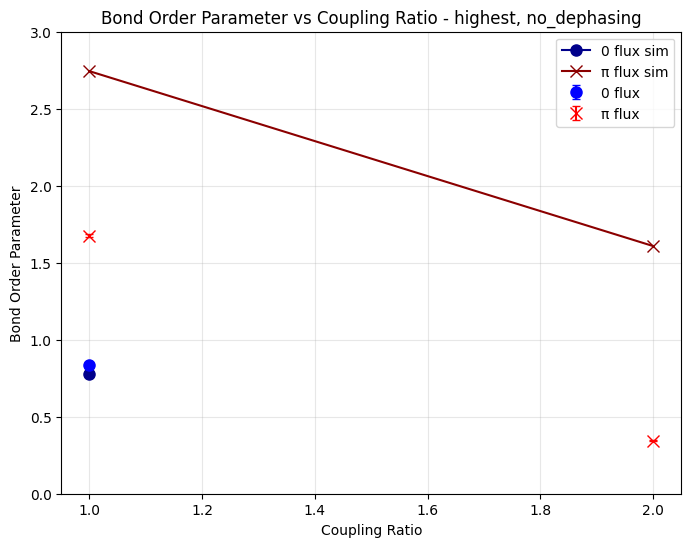

In [312]:
# Example usage
fig, ax = plt.subplots(figsize=(8, 6))
plot_bond_order_parameter_vs_ratio(ax, data, eigenstate, dephasing, coupling_point_to_ratio)
ax.set_title(f'Bond Order Parameter vs Coupling Ratio - {eigenstate}, {dephasing}')
plt.show()

# 8. Bond Order Matrix

In [313]:
def build_bond_order_matrix(
    data,
    coupling_point,
    eigenstate,
    pairs,
    use_corrected   = True,
    normalize       = False,
):
    """Build 1-row bond order matrix."""
    key = 'bond_order_value_corrected' if use_corrected else 'bond_order_value'
    
    bond_order_values = []
    for pair in pairs:
        try:
            val = data['data'][coupling_point][eigenstate][str(pair)][key]
            bond_order_values.append(val)
        except KeyError:
            bond_order_values.append(np.nan)
    
    matrix = np.array(bond_order_values).reshape(1, -1)
    
    if normalize:
        max_val = np.nanmax(np.abs(matrix))
        if max_val > 0:
            matrix = matrix / max_val
    
    return matrix, pairs

def build_bond_order_matrix_sim(
    data,
    coupling_point,
    eigenstate,
    dephasing,
    pairs,
    use_BS          = True,
    normalize       = False,
):
    """Build 1-row bond order matrix from simulation."""
    key = 'bond_order_value_BS' if use_BS else 'bond_order_value'
    
    bond_order_values = []
    for pair in pairs:
        try:
            val = data['simulation'][eigenstate][dephasing][coupling_point][str(pair)][key]
            bond_order_values.append(val)
        except KeyError:
            bond_order_values.append(np.nan)
    
    matrix = np.array(bond_order_values).reshape(1, -1)
    
    if normalize:
        max_val = np.nanmax(np.abs(matrix))
        if max_val > 0:
            matrix = matrix / max_val
    
    return matrix, pairs

In [314]:
def plot_bond_order_matrix(
    ax,
    matrix,
    pairs,
    cmap            = 'RdBu_r',
    vmin            = None,
    vmax            = None,
    annotate        = True,
    font_size       = 12,
    nan_color       = 'lightgray',
    show_colorbar   = True,
):
    """Plot 1-row bond order matrix as heatmap."""
    cmap_obj = mpl.colormaps[cmap].copy()
    cmap_obj.set_bad(color=nan_color)
    
    # Symmetric color scale if not specified
    if vmin is None and vmax is None:
        max_abs = np.nanmax(np.abs(matrix))
        vmin, vmax = -max_abs, max_abs
    
    im = ax.imshow(matrix, cmap=cmap_obj, vmin=vmin, vmax=vmax, aspect='equal')
    
    # Annotate cells
    if annotate:
        for j in range(matrix.shape[1]):
            val = matrix[0, j]
            if not np.isnan(val):
                text_color = 'white' if abs(val) > 0.5 * max(abs(vmin), abs(vmax)) else 'black'
                ax.text(j, 0, f'{val:.2f}', ha='center', va='center',
                        fontsize=font_size - 2, color=text_color)
    
    # Labels
    ax.set_xticks(range(len(pairs)))
    ax.set_xticklabels([f'{p[0]}-{p[1]}' for p in pairs], fontsize=font_size - 2)
    ax.set_yticks([])
    ax.set_xlabel('Rung', fontsize=font_size - 2)
    
    if show_colorbar:
        cbar = plt.colorbar(im, ax=ax, orientation='vertical')
        cbar.ax.tick_params(labelsize=font_size - 3)
    
    return im

In [315]:
def plot_bond_order_matrix_data_and_sim(
    ax,
    data,
    coupling_point,
    eigenstate,
    dephasing,
    pairs,
    use_corrected       = True,
    normalize           = False,
    annotate            = True,
    font_size           = 12,
    nan_color           = 'lightgray',
    use_same_scale      = True,
):
    """Plot data and sim bond order matrices stacked vertically."""
    fig = ax.figure
    pos = ax.get_position()
    ax.remove()
    
    # Create two subplots in the same space
    ax_data = fig.add_axes([pos.x0, pos.y0 + pos.height/2, pos.width * 0.85, pos.height/2])
    ax_sim = fig.add_axes([pos.x0, pos.y0, pos.width * 0.85, pos.height/2])
    ax_cbar = fig.add_axes([pos.x0 + pos.width * 0.88, pos.y0, pos.width * 0.05, pos.height])
    
    # Build matrices
    matrix_data, _ = build_bond_order_matrix(data, coupling_point, eigenstate, pairs, 
                                              use_corrected=use_corrected, normalize=normalize)
    matrix_sim, _ = build_bond_order_matrix_sim(data, coupling_point, eigenstate, dephasing, pairs,
                                                 normalize=normalize)
    
    # Determine color scale
    if use_same_scale:
        all_vals = np.concatenate([matrix_data.flatten(), matrix_sim.flatten()])
        max_abs = np.nanmax(np.abs(all_vals))
        vmin, vmax = -max_abs, max_abs
    else:
        vmin, vmax = None, None
    
    cmap_obj = plt.cm.RdBu_r.copy()
    cmap_obj.set_bad(color=nan_color)
    
    # Plot data
    im_data = ax_data.imshow(matrix_data, cmap=cmap_obj, vmin=vmin, vmax=vmax, aspect='equal')
    ax_data.set_xticks([])
    ax_data.set_yticks([0])
    ax_data.set_yticklabels(['Data'], fontsize=font_size - 2)
    
    # Plot sim
    im_sim = ax_sim.imshow(matrix_sim, cmap=cmap_obj, vmin=vmin, vmax=vmax, aspect='equal')
    ax_sim.set_xticks(range(len(pairs)))
    ax_sim.set_xticklabels([f'{p[0]}-{p[1]}' for p in pairs], fontsize=font_size - 2)
    ax_sim.set_yticks([0])
    ax_sim.set_yticklabels(['Sim'], fontsize=font_size - 2)
    ax_sim.set_xlabel('Rung', fontsize=font_size - 2)
    
    # Annotate
    if annotate:
        for j in range(len(pairs)):
            for ax_curr, mat in [(ax_data, matrix_data), (ax_sim, matrix_sim)]:
                val = mat[0, j]
                if not np.isnan(val):
                    text_color = 'white' if abs(val) > 0.5 * max_abs else 'black'
                    ax_curr.text(j, 0, f'{val:.2f}', ha='center', va='center',
                                fontsize=font_size - 3, color=text_color)
    
    # Colorbar
    plt.colorbar(im_data, cax=ax_cbar)
    ax_cbar.tick_params(labelsize=font_size - 3)

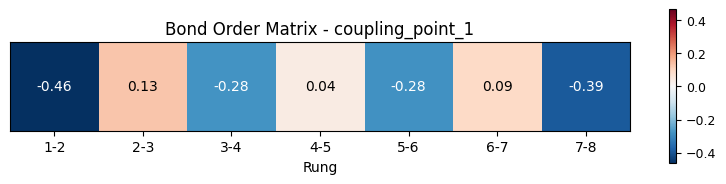

In [316]:
# Example: single matrix
fig, ax = plt.subplots(figsize=(10, 2))
matrix, _ = build_bond_order_matrix(data, coupling_point, eigenstate, pairs)
plot_bond_order_matrix(ax, matrix, pairs)
ax.set_title(f'Bond Order Matrix - {coupling_point}')
plt.show()

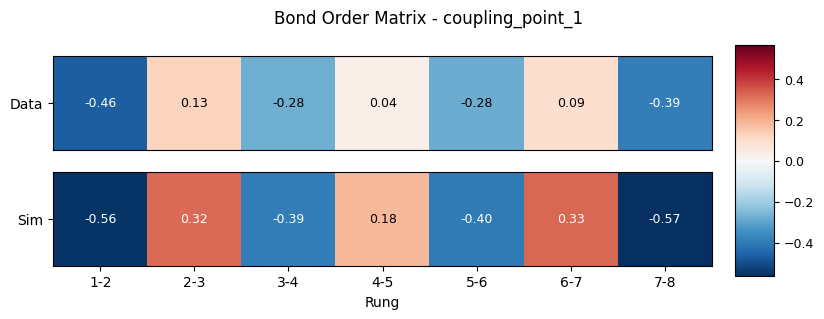

In [317]:
# Example: data and sim comparison
fig, ax = plt.subplots(figsize=(10, 3))
plot_bond_order_matrix_data_and_sim(ax, data, coupling_point, eigenstate, dephasing, pairs)
fig.suptitle(f'Bond Order Matrix - {coupling_point}', y=1.00)

# plt.savefig(f'saved_figures/cp{coupling_point[-1]}_{eigenstate[:3]}_{dephasing}_bondordermatrix.png', dpi=300, bbox_inches='tight')
plt.show()

# 9. Utility: Compute Total Bond Order

In [318]:
def compute_total_bond_order(bond_order_values):
    """Compute total bond order: sum of (-1)^i * b_i."""
    alternating = np.array([(-1)**i for i in range(len(bond_order_values))])
    return np.dot(bond_order_values, alternating)

In [319]:
# Example: verify total bond order calculation
bond_order_values = [data['data']['coupling_point_4'][eigenstate][str(pair)]['bond_order_value_corrected'] for pair in pairs]
print(f'Total bond order: {compute_total_bond_order(bond_order_values):.4f}')

Total bond order: -0.8336


# 10. Summary Figure

In [320]:
def create_summary_figure(
    data,
    eigenstate,
    dephasing,
    pairs,
    coupling_point_to_ratio,
    coupling_point_example  = 'coupling_point_1',
    figsize                 = (14, 10),
):
    """Create a summary figure with multiple panels."""
    fig = plt.figure(figsize=figsize)
    
    # Layout: 2x2 grid
    ax1 = fig.add_subplot(2, 2, 1)  # Bond order vs time (single example)
    ax2 = fig.add_subplot(2, 2, 2)  # Bond order values vs rung
    ax3 = fig.add_subplot(2, 2, 3)  # All coupling points comparison
    ax4 = fig.add_subplot(2, 2, 4)  # Bond order parameter vs ratio
    
    # Panel 1: Bond order vs time for one pair
    plot_bond_order_time(ax1, data, coupling_point_example, eigenstate, pairs[0])
    ax1.set_title(f'Bond Order vs Time - {pairs[0]}')
    
    # Panel 2: Bond order values vs rung (data + sim)
    plot_bond_order_data_and_sim(ax2, data, coupling_point_example, eigenstate, dephasing, pairs)
    ax2.set_title(f'Bond Order vs Rung - {coupling_point_example}')
    
    # Panel 3: All coupling points
    plot_bond_order_all_coupling_points(ax3, data, eigenstate, dephasing, pairs, plot_sim=False)
    ax3.set_title('All Coupling Points')
    
    # Panel 4: Bond order parameter vs ratio
    plot_bond_order_parameter_vs_ratio(ax4, data, eigenstate, dephasing, coupling_point_to_ratio)
    ax4.set_title('Bond Order Parameter vs Coupling Ratio')
    
    plt.tight_layout()
    # plt.savefig(f'saved_figures/cp{coupling_point[-1]}_{eigenstate[:3]}_{dephasing}_bondorder_summary.png', dpi=300, bbox_inches='tight')
    plt.show()

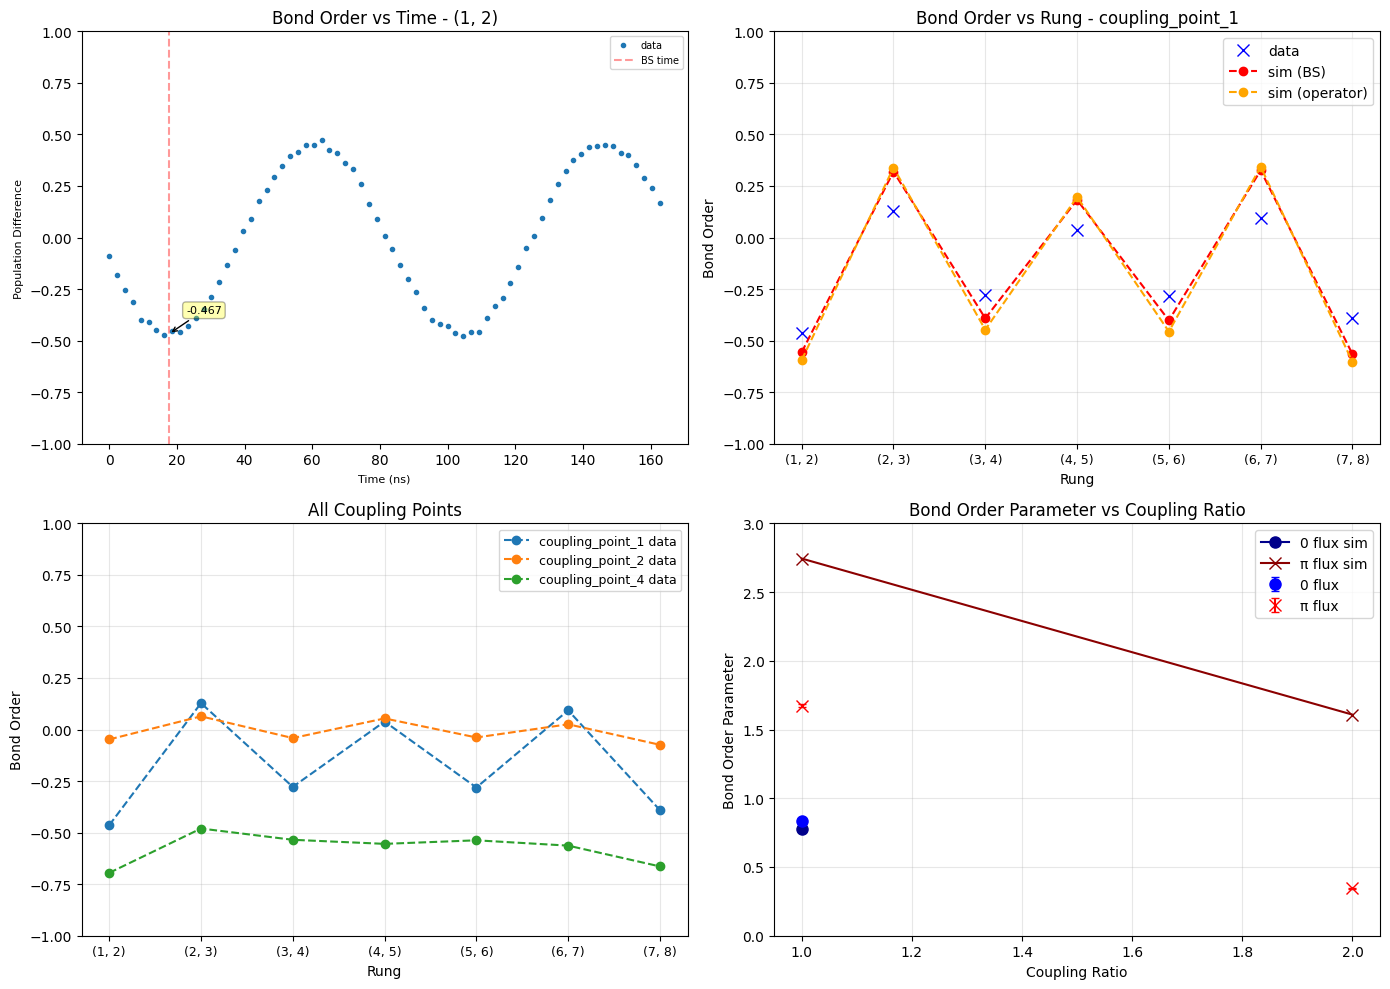

In [321]:
# Example usage
create_summary_figure(data, eigenstate, dephasing, pairs, coupling_point_to_ratio, coupling_point_example="coupling_point_1")